# Kepler-51 planetary system in the light of the PhotoRing effect
## Reproducing the figures of Numpaque et al. (2026)

This notebook contains the code for reproducing the figures in the paper:

> S. Numpaque, J.I. Zuluaga, D. Kipping and J.A. Alvarado "Asterodensity profile analysis of the Kepler-51 planetary system:1
a case study on the detection of exoplanetary rings via the PhotoRing effect", in preparation.

For detailed explanations see the GitHub repository: [https://github.com/seap-udea/PRisma](https://github.com/seap-udea/PRisma).

## Preparing the environment

In [1]:
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline").is_dir() and (c / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO), str(_REPO / "pipeline")):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)


repo root: /Users/jzuluaga/dev/PRisma


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot
from photoring import literature, contour
from photoring.io import load_observables, load_run
from dynesty import plotting as _dyplot
from scipy.stats import wasserstein_distance, ks_2samp, energy_distance
from matplotlib.ticker import AutoMinorLocator


# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

CASE = "kepler_51"
# This notebook does not live in pipeline/, so point CasePaths at it explicitly.
paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
IMG = pathlib.Path(_REPO / "papers" / "kepler51" / "figures")
# Posterior chains behind the manuscript figures, versioned as reference artefacts.
REFERENCE_RUNS = pathlib.Path(_REPO / "papers" / "kepler51" / "reference_runs")
IMG.mkdir(parents=True, exist_ok=True)
print("writing figures to:", IMG)

def run_version_id(files):
    """YYYYMMDDHH stamp from the newest file mtime (campaign identifier)."""
    from datetime import datetime
    files = [pathlib.Path(f) for f in files if f is not None and pathlib.Path(f).exists()]
    if not files:
        return "unknown"
    newest = max(files, key=lambda p: p.stat().st_mtime)
    return datetime.fromtimestamp(newest.stat().st_mtime).strftime("%Y%m%d%H")


def add_run_version_label(fig, version, *, x=0.988, y=0.98, fontsize=12, alpha=0.4):
    """Small vertical campaign stamp on the upper-right edge of the figure."""
    if not version or version == "unknown":
        return
    fig.text(
        x, y, str(version),
        rotation=90, va="top", ha="right",
        fontsize=fontsize, alpha=alpha, color="0.25",
        transform=fig.transFigure, clip_on=False,
    )


writing figures to: /Users/jzuluaga/dev/PRisma/papers/kepler51/figures


## 1. Configuration — the adopted runs

The manuscript's ring-geometry figures use the **fully free** model
($f_e,\ i_R,\ \theta,\ p,\ \tau,\ \rho_{\star,\rm true},\ b$ all sampled) with the likelihood
$\mathcal{L}_{\rm KDE} = (\delta,\ T_{14},\ \rho_{\star,\rm obs})$, nested sampling at
$N_{\rm live}=1200$ and $\Delta\ln Z = 0.01$, and $N_{\rm KDE}=5000$ training samples.

That combination was adopted because it is the only one in the retrieval suite that
reproduces the **full** set of transit observables — including the ones left out of the
likelihood. Simpler configurations fit their own likelihood observables but mispredict the
durations.


In [3]:
RUN_SUFFIX = ("NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01"
              "_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE")
PLANETS = ["b", "d"]

runs = {}
for pl in PLANETS:
    npz = REFERENCE_RUNS / f"{CASE}_{pl}_{RUN_SUFFIX}.npz"
    if not npz.exists():
        print(f"MISSING: {npz.name}")
        continue
    runs[pl] = load_run(npz)
    r = runs[pl]
    print(f"planet {pl}: ndim={len(r['param_names'])}  lnZ={r['logz']:.3f}  "
          f"L_KDE={r['kde_obs']}  n={len(r['chain'])}")

ttv = {pl: load_observables(paths.observables_file(pl)) for pl in PLANETS}
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3
print("\nTTV observables loaded:", {k: len(v["delta"]) for k, v in ttv.items()})

npz_used = [REFERENCE_RUNS / f"{CASE}_{pl}_{RUN_SUFFIX}.npz" for pl in PLANETS]
RUN_VERSION = run_version_id(npz_used)
print("RUN_VERSION:", RUN_VERSION)


planet b: ndim=7  lnZ=1.657  L_KDE=['delta', 'T14', 'rho_obs']  n=16923
planet d: ndim=7  lnZ=1.572  L_KDE=['delta', 'T14', 'rho_obs']  n=15111

TTV observables loaded: {'b': 17756, 'd': 39002}
RUN_VERSION: 2026073013


## PPC analysis

In [4]:
# ══════════════════════════════════════════════════════════════════════════
#  STYLE
# ══════════════════════════════════════════════════════════════════════════
STYLE = {
    # Typography
    "font_family": "serif",
    "font_size": 18,
    "annot_size": 12,
    "title_size": 20,
    "label_size": 18,
    "tick_size": 12,
    "legend_size": 13,
    "use_latex": False,      # True -> full LaTeX rendering (needs texlive)
    "math_font": "cm",

    # Palette (pastel astronomical)
    "c_posterior": "#A8C8E8",
    "c_data": "#808080",
    "c_prior": "#F5C5A0",
    "c_ppc_in": "#A8D8C8",
    "c_ppc_out": "#F5C5A0",
    "c_planet_b": "#A2BCCE",
    "c_planet_d": "#9AC2B8",
    "c_median": "#3D424A",
    "c_interval": "#4B5666",
    "c_accent": "#E88A6A",
    "c_corner_2d": "#7FB3D3",
    "c_corner_1d": "#6487AA",
    "c_logz": "#9CC2A5",
    "c_logl": "#E8A8A8",

    # Figure geometry
    "fig_dpi": 200,
    "fig_w_single": 3.5,
    "fig_h_single": 3.5,
    "fig_w_ppc": 4.2,
    "hspace": 0.2,
    "wspace": 0.2,

    # Lines and fills
    "hist_alpha": 0.8,
    "hist_bins": "scott",
    "hist_edgecolor": "none",
    "line_lw": 1.2,
    "line_lw_thin": 1.2,
    "spine_lw": 1.2,
    "contour_alpha": 0.85,
    "contour_smooth": 1.5,

    # Median / credible-interval markers drawn by _annotate_stats
    "median_ls": "--",
    "median_lw": 1.2,
    "median_alpha": 0.85,
    "sigma_ls": ":",
    "sigma_lw": 0.7,
    "sigma_alpha": 0.50,

    # Literature overlays (unfilled reference curves)
    "lit_lw": 1.5,
    "lit_alpha": 0.90,
    "lit_ls": "-",

    # Grid and spines
    "show_grid": True,
    "grid_alpha": 0.1,
    "grid_lw": 0.2,
    "minor_ticks": True,
    "top_spine": False,
    "right_spine": False,

    # Corner-specific
    # NOTE: dynesty's own default is the 95% interval [0.025, 0.5, 0.975]; the
    # published figures use that default (see PAPER_STYLE).
    "corner_quantiles": [0.16, 0.5, 0.84],
    "corner_levels": [0.393, 0.865],
    # Corner smoothing, as a *fraction of each parameter's plotted span* — this is
    # dynesty's own convention, and is not the same quantity as `contour_smooth`
    # (which counts bins). Values above ~0.1 wash the posterior out entirely.
    "corner_smooth": 0.02,

    # Output
    "fig_format": "png",
    "transparent": False,
}

# Default per-planet display names. Override per case with :func:`set_case_labels`.
PLANET_LABELS = {"b": "Kepler-51 b", "c": "Kepler-51 c", "d": "Kepler-51 d"}

PARAM_META = {
    "fe":       dict(label=r"$f_e\,[R_p]$", desc="Outer ring radius", symbol=r"$f_e$"),
    "ir":       dict(label=r"$i_R\,$[deg]", desc="Ring inclination", symbol=r"$i_R$"),
    "theta":    dict(label=r"$\theta\,$[deg]", desc="Ring projected tilt", symbol=r"$\theta$"),
    "p":        dict(label=r"$p=R_p/R_\star$", desc="Planet radius ratio", symbol=r"$p$"),
    "tau":      dict(label=r"$\tau$", desc="Ring opacity", symbol=r"$\tau$"),
    "rho_true": dict(label=r"$\rho_{\star,\rm true}\,$[g/cm$^3$]",
                     desc="True stellar density", symbol=r"$\rho_{\star,\rm true}$"),
    "b":        dict(label=r"$b$", desc="Impact parameter", symbol=r"$b$"),
}

def param_meta(name):
    """Metadata for a model-parameter name, falling back to the bare name."""
    return PARAM_META.get(name, dict(label=name, desc=name, symbol=name))

#: Fallback cycle for cases with more planets than the palette names explicitly.
_PLANET_COLOR_CYCLE = ["#A6CEE8", "#90DBC7", "#F5C5A0", "#C8B0E8", "#E8C8B0"]
_PLANET_LINE_CYCLE = ["#0072B2", "#009E73", "#C17D11", "#6A3D9A", "#8B4513"]

OBS_META = {
    "delta": dict(
        df_col="delta", ppc_col=0, scale=1e6, unit="ppm",
        symbol=r"$\delta$", label=r"$\delta$ [ppm]",
        xlabel=r"Transit depth $\delta$ [ppm]", short="Transit depth"),
    "T14": dict(
        df_col="T14", ppc_col=1, scale=1.0, unit="h",
        symbol=r"$T_{14}$", label=r"$T_{14}$ [h]",
        xlabel=r"Total duration $T_{14}$ [h]", short="Total duration"),
    "T23": dict(
        df_col="T23", ppc_col=2, scale=1.0, unit="h",
        symbol=r"$T_{23}$", label=r"$T_{23}$ [h]",
        xlabel=r"Flat duration $T_{23}$ [h]", short="Flat duration"),
    "rho_obs": dict(
        df_col="rho_obs_gcc", ppc_col=3, scale=1.0, unit=r"g cm$^{-3}$",
        symbol=r"$\rho_{\star,\rm obs}$",
        label=r"$\rho_{\star,\rm obs}$ [g cm$^{-3}$]",
        xlabel=r"Stellar density $\rho_{\star,\rm obs}$ [g cm$^{-3}$]",
        short="Obs. density"),
    "b_obs": dict(
        df_col="b", ppc_col=4, scale=1.0, unit="",
        symbol=r"$b_{\rm obs}$", label=r"$b_{\rm obs}$",
        xlabel=r"Impact parameter $b_{\rm obs}$", short="Impact parameter"),
    "aR": dict(
        df_col="aR", ppc_col=None, scale=1.0, unit="",
        symbol=r"$a/R_{\star}$", label=r"$a/R_{\star}$",
        xlabel=r"Scaled semimajor axis $a/R_{\star}$", short="Scaled semimajor axis"),
}

def obs_meta(key):
    """Metadata for an observable key, with a clear error for unknown keys."""
    try:
        return OBS_META[key]
    except KeyError:
        raise KeyError(
            f"Unknown observable {key!r}. Known keys: {sorted(OBS_META)}") from None

# Observables predicted by the forward model, in PPC column order.
ALL_OBS_KEYS = [k for k, m in sorted(OBS_META.items(), key=lambda kv: (kv[1]["ppc_col"] is None,
                                                                      kv[1]["ppc_col"] or 0))
                if m["ppc_col"] is not None]


#: Fallback cycle for cases with more planets than the palette names explicitly.
_PLANET_COLOR_CYCLE = ["#A6CEE8", "#90DBC7", "#F5C5A0", "#C8B0E8", "#E8C8B0"]
_PLANET_LINE_CYCLE = ["#0072B2", "#009E73", "#C17D11", "#6A3D9A", "#8B4513"]

def planet_color(planet, kind="fill"):
    """Palette colour for a planet key.

    ``kind`` selects ``"fill"`` (histograms, ring patches), ``"line"`` (KDE curves,
    median markers) or ``"corner"`` (corner-plot ink). Planets beyond those named in
    :data:`STYLE` fall back to a deterministic cycle keyed on the planet letter, so a
    case with more than two planets still gets stable, distinct colours.
    """
    prefix = "c_corner_" if kind == "corner" else "c_planet_"
    suffix = "_line" if kind == "line" else ""
    explicit = STYLE.get(f"{prefix}{planet}{suffix}")
    if explicit:
        return explicit
    # "corner"/"line" not declared for this planet -> fall back to its fill colour.
    if kind != "fill":
        fallback = STYLE.get(f"c_planet_{planet}")
        if fallback:
            return fallback

    # Unnamed planet: take the next cycle entry not already claimed by an explicit
    # STYLE colour, so a third planet never collides with b's or d's colour.
    cycle = _PLANET_LINE_CYCLE if kind == "line" else _PLANET_COLOR_CYCLE
    claimed = {v for k, v in STYLE.items()
               if k.startswith("c_planet_") and isinstance(v, str)}
    free = [c for c in cycle if c not in claimed] or cycle
    unnamed = [p for p in sorted(PLANET_LABELS) if not STYLE.get(f"c_planet_{p}")]
    idx = unnamed.index(planet) if planet in unnamed else 0
    return free[idx % len(free)]


def _hist1d(ax, data, color, label, bins=None, density=True, alpha=None, zorder=2):
    b = bins or STYLE["hist_bins"]
    a = alpha if alpha is not None else STYLE["hist_alpha"]
    ax.hist(data, bins=b, density=density, color=color, alpha=a,
            edgecolor=STYLE["hist_edgecolor"], zorder=zorder, label=label)



# ── PPC statistics ───────────────────────────────────────────────────────────
def ppc_stats_1d(emp, pred):
    """Wasserstein-1, KS (+ p-value) and Energy distance between two 1-D sample sets."""
    emp = np.asarray(emp, dtype=float); emp = emp[np.isfinite(emp)]
    pred = np.asarray(pred, dtype=float); pred = pred[np.isfinite(pred)]
    W1 = float(wasserstein_distance(emp, pred))
    KS, KS_p = ks_2samp(emp, pred)
    E = float(energy_distance(emp, pred))
    return dict(W1=W1, KS=float(KS), KS_p=float(KS_p), E=E)

def _stats_legend_lines(stats, unit=""):
    u = f" {unit}" if unit else ""
    return [rf"$W_1 = {stats['W1']:.3g}${u}",
            rf"$E = {stats['E']:.3g}${u}"]

# ── low-level helpers ────────────────────────────────────────────────────────
def _style_ax(ax, xlabel="", ylabel="Density", title="", legend=True):
    ax.set_xlabel(xlabel, labelpad=4)
    ax.set_ylabel(ylabel, labelpad=4)
    if title:
        ax.set_title(title, fontsize=STYLE["title_size"])
    if legend:
        handles, labels = ax.get_legend_handles_labels()
        ncol = len(labels)
        # First panel: two rows, with Photo and Posterior together on top.
        if labels[:2] == ["Photo", "Posterior"] and len(labels) == 4:
            order = [0, 2, 1, 3]
            handles = [handles[i] for i in order]
            labels = [labels[i] for i in order]
            ncol = 2
        ax.legend(handles, labels, fontsize=STYLE["legend_size"], framealpha=0.85,
                  edgecolor="#cccccc", fancybox=False, ncol=ncol,
                  loc="lower center", bbox_to_anchor=(0.5, 1.04), borderaxespad=0)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    return ax

def _run_title(run):
    r"""``L_KDE: [obs…]   \hat{theta}: [params…]`` — which data constrained which parameters."""
    kde_symbols = r" \; ".join(obs_meta(k)["symbol"].replace("$", "")
                               for k in run["kde_obs"])
    par_symbols = r" \; ".join(param_meta(p)["symbol"].replace("$", "")
                               for p in run["param_names"])
    params = []
    etas = []
    qeta = False
    for p in run["param_names"]:
        if 'true' in param_meta(p)["symbol"]:
            qeta = True
        if not qeta:
            params += [param_meta(p)["symbol"].replace("$", "")]
        if qeta:
            etas += [param_meta(p)["symbol"].replace("$", "")]
    par_symbols = r" \; ".join(params)
    eta_symbols = r" \; ".join(etas)

    return (rf"$\mathcal{{L}}_{{\mathrm{{KDE}}}}\text{{: }}"
            rf"\left[ {kde_symbols} \right]"
            rf" \qquad \boldsymbol{{{{\theta}}}}\text{{: }}"
            rf"\left[ {par_symbols} \right]"
            rf" \qquad \boldsymbol{{{{\eta}}}}\text{{: }}"
            rf"\left[ {eta_symbols} \right]"
            rf"$"
            )

# ══════════════════════════════════════════════════════════════════════════
#  Posterior predictive check
# ══════════════════════════════════════════════════════════════════════════
def _ppc_entries(run, ttv, keys):
    entries = []
    ppc = run["ppc"]
    for key in keys:
        meta = obs_meta(key)
        col, scale = meta["ppc_col"], meta["scale"]
        if col is None:
            continue  # not predicted by the forward model (e.g. aR)
        emp_raw = ttv.get(meta["df_col"], np.array([]))
        pred_raw = ppc[:, col] if (ppc is not None and ppc.ndim == 2 and col < ppc.shape[1]) else np.array([])
        emp = np.asarray(emp_raw).ravel() * scale
        pred = np.asarray(pred_raw).ravel() * scale
        emp = emp[np.isfinite(emp)]; pred = pred[np.isfinite(pred)]
        if len(emp) and len(pred):
            entries.append((key, emp, pred, meta["label"]))
    return entries


def plot_ppc(run, ttv, obs_keys=None, paths=None):
    """Posterior-predictive check: Photo vs predicted distributions with GoF statistics."""
    planet = run["planet"]
    keys = obs_keys if obs_keys is not None else ALL_OBS_KEYS
    entries = _ppc_entries(run, ttv, keys)
    if not entries:
        print(f"No PPC data for {run['tag']} — skipping.")
        return None, {}
    all_stats = {key: ppc_stats_1d(emp, pred) for key, emp, pred, _ in entries}

    n = len(entries)
    W = STYLE["fig_w_ppc"]
    fig, axes = plt.subplots(n, 1, figsize=(W * 1.5, STYLE["fig_h_single"] * n * 0.85),
                             squeeze=False)
    axes = axes[:, 0]
    col = planet_color(planet)
    for i, (ax, (key, emp, pred, lbl)) in enumerate(zip(axes, entries)):
        _lim = np.percentile(np.concatenate([emp, pred]), [0.5, 99.5])
        # Histogram identity (Photo / Posterior) only on the first panel.
        photo_lbl = "Photo" if i == 0 else None
        post_lbl = "Posterior" if i == 0 else None
        _hist1d(ax, emp, STYLE["c_data"], photo_lbl, alpha=0.55)
        _hist1d(ax, pred, col, post_lbl, alpha=0.65)
        ax.set_xlim(_lim)
        for s in _stats_legend_lines(all_stats[key], unit=obs_meta(key)["unit"]):
            ax.plot([], [], color="none", label=s)
        _style_ax(ax, xlabel=lbl, legend=True)
    fig.suptitle(f"Posterior Predictive Check — {PLANET_LABELS.get(planet, planet)}\n{_run_title(run)}",
                 fontsize=STYLE["title_size"] * 0.78, y=0.975)
    # Reserve explicit gaps for legends while keeping the first panel close to the title.
    fig.subplots_adjust(left=0.14, right=0.97, bottom=0.06, top=0.88, hspace=0.95)
    return fig, all_stats

-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/ppc_planet_b_vertical.png
-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/ppp_planet_d_vertical.png


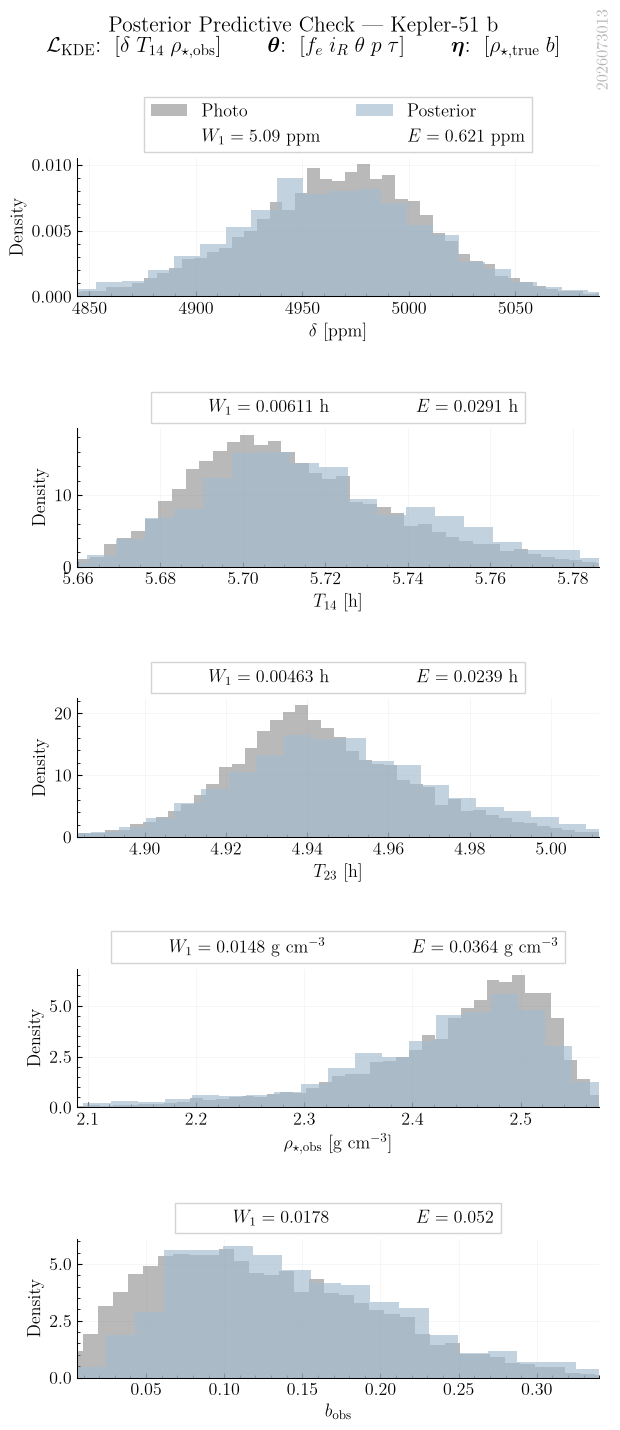

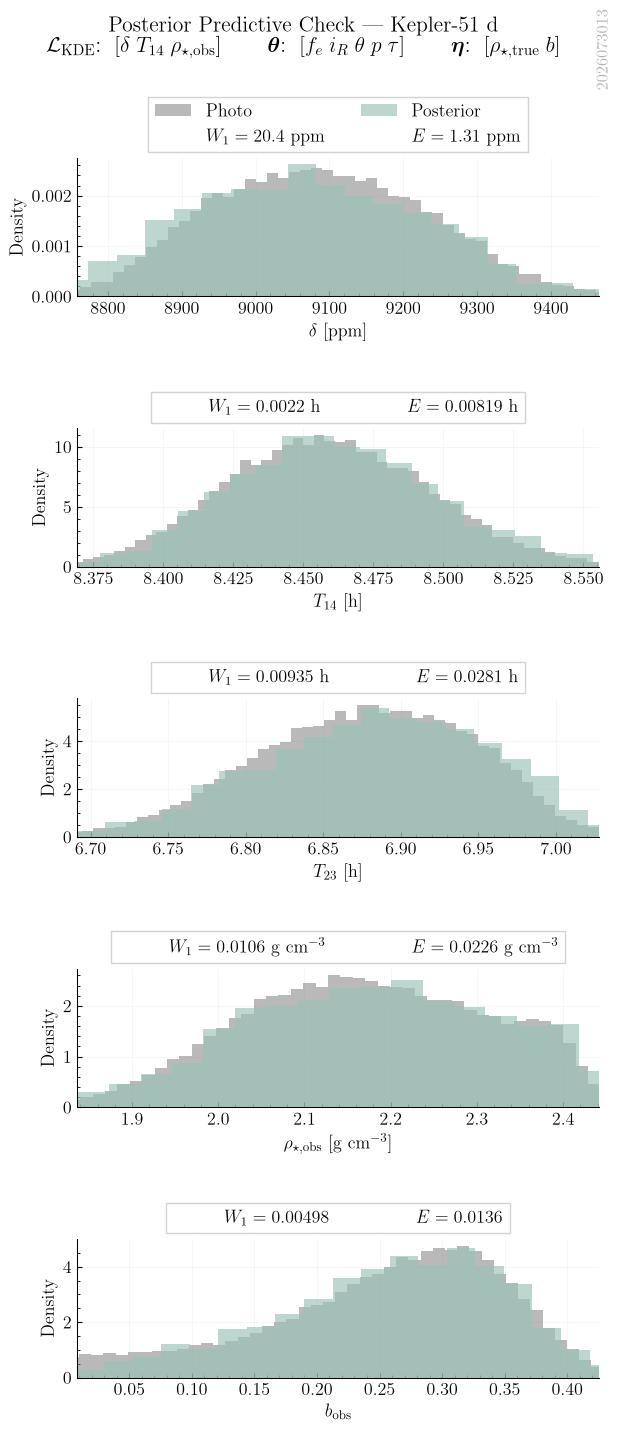

In [5]:
PPC_NAME = {"b": "ppc_planet_b_vertical.png", "d": "ppp_planet_d_vertical.png"}
PPC_OBSERVABLES = ["delta", "T14", "T23", "rho_obs", "b_obs"]

ppc_stats = {}
for pl, run in runs.items():
    fig, stats = plot_ppc(run, ttv[pl], obs_keys=PPC_OBSERVABLES)
    ppc_stats[pl] = stats
    out = IMG / PPC_NAME[pl]
    add_run_version_label(fig, RUN_VERSION)
    fig.savefig(out, dpi=STYLE["fig_dpi"], bbox_inches="tight")
    print("->", out)
    # break
    # plt.close(fig)
